 Heart Disease Prediction
 Group C
23/06334 Danniel Ojijo,
23/06401 Tamia Mwandu,
23/06590 Benedict Masila,
23/05920 Cindy Chesum,
22/06401 Kemboi Kevin,

# New Section

In [17]:

%pip install flask flask-cors ucimlrepo scikit-learn pandas numpy --quiet


In [18]:
import threading
import pandas as pd
import numpy as np

from flask import Flask, request, jsonify
from flask_cors import CORS
from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('All imports successful ✓')


All imports successful ✓


## Load dataset & inspect it

In [19]:
# Fetch the UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print('--- Dataset metadata ---')
print(heart_disease.metadata)
print()
print('--- Variable information ---')
print(heart_disease.variables)
print()
print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
X.head()


--- Dataset metadata ---
{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


##  Preprocess & train the model

In [20]:
# Flatten target to binary: 0 = no disease, 1 = disease present
y_binary = y.squeeze()
y_binary = (y_binary > 0).astype(int)

# Combine and drop rows with missing values
data_clean = pd.concat([X, y_binary], axis=1).dropna()
X_clean = data_clean.iloc[:, :-1]
y_clean = data_clean.iloc[:, -1]

FEATURE_COLS = X_clean.columns.tolist()
print(f'Feature columns  : {FEATURE_COLS}')
print(f'Rows after dropna: {len(X_clean)}')
print(f'Class balance    : {y_clean.value_counts().to_dict()}  (0=healthy, 1=disease)')

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clean, test_size=0.2, random_state=42
)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f'\nModel accuracy on test set: {accuracy:.2%} ✓')

Feature columns  : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Rows after dropna: 297
Class balance    : {0: 160, 1: 137}  (0=healthy, 1=disease)

Model accuracy on test set: 88.33% ✓


COMPARE MODELS - Random Forest vs Others



Training Logistic Regression...
Training SVM...

ACCURACY SCORES
Random Forest:      0.883 (88.3%)
Logistic Regression: 0.867 (86.7%)
SVM:                0.883 (88.3%)


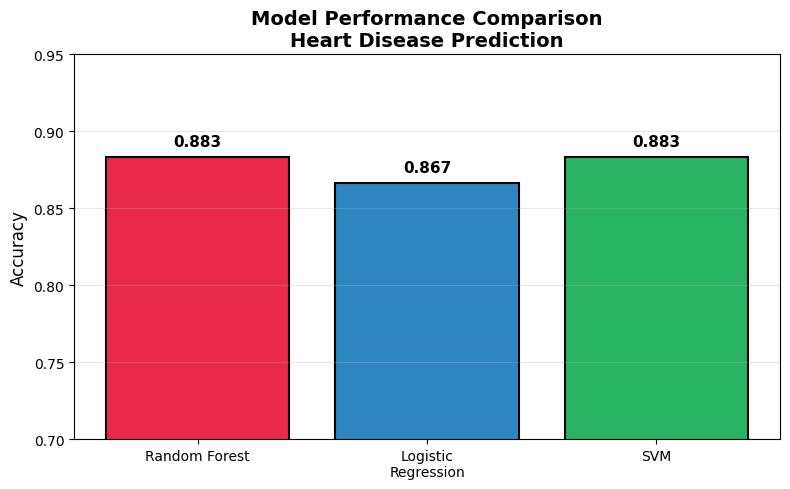

In [29]:

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Train models
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))

print("Training SVM...")
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm_model.predict(X_test))

# Random Forest accuracy (already have)
rf_acc = accuracy_score(y_test, model.predict(X_test))

# Display numbers
print("\n" + "="*35)
print("ACCURACY SCORES")
print("="*35)
print(f"Random Forest:      {rf_acc:.3f} ({rf_acc:.1%})")
print(f"Logistic Regression: {lr_acc:.3f} ({lr_acc:.1%})")
print(f"SVM:                {svm_acc:.3f} ({svm_acc:.1%})")
print("="*35)

# Single bar chart
plt.figure(figsize=(8, 5))
models = ['Random Forest', 'Logistic\nRegression', 'SVM']
scores = [rf_acc, lr_acc, svm_acc]
colors = ['#e8294a', '#2e86c1', '#28b463']

bars = plt.bar(models, scores, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Performance Comparison\nHeart Disease Prediction', fontsize=14, fontweight='bold')
plt.ylim(0.7, 0.95)

# Add numbers on bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

##  Feature importance



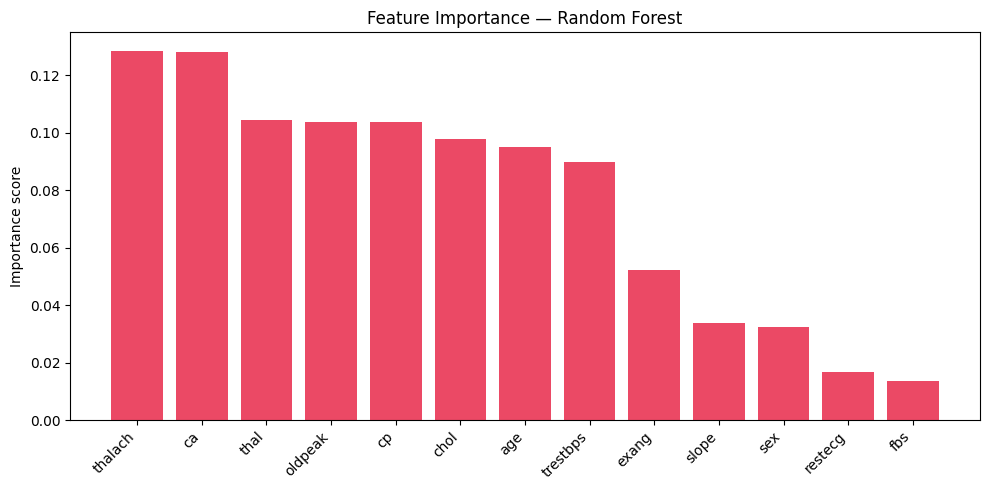

Top 3 most predictive features:
  thalach      0.1286
  ca           0.1283
  thal         0.1045


In [22]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(FEATURE_COLS)), importances[sorted_idx], color='#e8294a', alpha=0.85)
plt.xticks(range(len(FEATURE_COLS)), [FEATURE_COLS[i] for i in sorted_idx], rotation=45, ha='right')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance score')
plt.tight_layout()
plt.show()

print('Top 3 most predictive features:')
for i in sorted_idx[:3]:
    print(f'  {FEATURE_COLS[i]:<12} {importances[i]:.4f}')

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Disease']))

Confusion Matrix:
[[32  4]
 [ 3 21]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.91      0.89      0.90        36
     Disease       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



##  Define Flask app & routes

In [24]:
app = Flask(__name__)
CORS(app)  # Allows index.html (opened as a local file) to call this API

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()

        # Build feature row in the same column order the model was trained on
        row = [float(data[col]) for col in FEATURE_COLS]
        row_scaled = scaler.transform([row])

        prob        = float(model.predict_proba(row_scaled)[0][1])
        prediction  = int(model.predict(row_scaled)[0])
        risk_level  = 'high' if prob >= 0.65 else ('moderate' if prob >= 0.35 else 'low')

        return jsonify({
            'probability': round(prob, 4),
            'prediction' : prediction,
            'risk_level' : risk_level
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 400


@app.route('/health', methods=['GET'])
def health():
    return jsonify({
        'status'  : 'ok',
        'model'   : 'RandomForest',
        'accuracy': f'{accuracy:.2%}',
        'features': FEATURE_COLS
    })


print('Flask routes defined ✓')
print('  POST /predict  — send patient data, receive risk probability')
print('  GET  /health   — check server status')

Flask routes defined ✓
  POST /predict  — send patient data, receive risk probability
  GET  /health   — check server status


## Cell 7 — Start the server


In [25]:
def run_server():
    # use_reloader=False is required inside a thread
    app.run(host='127.0.0.1', port=5000, debug=False, use_reloader=False)

# daemon=True means the thread dies automatically when the notebook shuts down
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print('Flask server running at http://127.0.0.1:5000 ✓')
print()
print('Next steps:')
print('  1. Open index.html in your browser')
print('  2. In index.html uncomment the fetchPredict() function')
print('  3. Fill in the form and click Analyse Risk')
print()
print('To stop the server → Kernel > Restart')


 * Serving Flask app '__main__'
Flask server running at http://127.0.0.1:5000 ✓

Next steps:
  1. Open index.html in your browser
  2. In index.html uncomment the fetchPredict() function
  3. Fill in the form and click Analyse Risk

To stop the server → Kernel > Restart
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


##  Quick test


In [26]:
%pip install requests


In [27]:
import requests  # standard library for HTTP calls
import time

time.sleep(1)  # give the server a moment to start

sample_patient = {
    'age': 63, 'sex': 1, 'cp': 3, 'trestbps': 145,
    'chol': 233, 'fbs': 1, 'restecg': 0, 'thalach': 150,
    'exang': 0, 'oldpeak': 2.3, 'slope': 3, 'ca': 0, 'thal': 6
}

response = requests.post('http://127.0.0.1:5000/predict', json=sample_patient)
result   = response.json()

print('Test patient result:')
print(f"  Probability : {result['probability']}")
print(f"  Prediction  : {'Disease present' if result['prediction'] == 1 else 'No disease'}")
print(f"  Risk level  : {result['risk_level']}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [06/Apr/2026 08:47:56] "POST /predict HTTP/1.1" 200 -


Test patient result:
  Probability : 0.31
  Prediction  : No disease
  Risk level  : low


In [28]:
# Test gender difference — identical metrics, different sex
base_patient = {
    'age': 55,
    'cp': 3,
    'trestbps': 140,
    'chol': 240,
    'fbs': 0,
    'restecg': 1,
    'thalach': 140,
    'exang': 0,
    'oldpeak': 1.0,
    'slope': 2,
    'ca': 1,
    'thal': 6
}

# Male version
male_patient = base_patient.copy()
male_patient['sex'] = 1

# Female version
female_patient = base_patient.copy()
female_patient['sex'] = 0

response_male = requests.post('http://127.0.0.1:5000/predict', json=male_patient)
response_female = requests.post('http://127.0.0.1:5000/predict', json=female_patient)

print("GENDER COMPARISON (same metrics, age 55):")
print(f"  Male risk:   {response_male.json()['probability']:.2%} ({response_male.json()['risk_level']})")
print(f"  Female risk: {response_female.json()['probability']:.2%} ({response_female.json()['risk_level']})")
print()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [06/Apr/2026 08:47:56] "POST /predict HTTP/1.1" 200 -
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
INFO:werkzeug:127.0.0.1 - - [06/Apr/2026 08:47:56] "POST /predict HTTP/1.1" 200 -


GENDER COMPARISON (same metrics, age 55):
  Male risk:   71.00% (high)
  Female risk: 62.00% (moderate)



# New Section